# Building a data cube with ODC-STAC

Load a time series of Sentinel-2 scenes over Rhodes directly from the cloud into a single, lazily-evaluated xarray data cube with `odc.stac.load`. Mask clouds and water with the scene-classification band, compute NDVI across time, and compare before/after the 2023 wildfire. Reads the Rhodes boundary from `../outputs/`; the imagery streams from the Earth Search STAC catalog (needs network).

## 1. Create a data cube with ODC-STAC

In [1]:
import geopandas
rhodes = geopandas.read_file("../outputs/rhodes.gpkg")
bbox = rhodes.total_bounds

In [2]:
import pystac_client

api_url = "https://earth-search.aws.element84.com/v1"
collection_id = "sentinel-2-c1-l2a"

client = pystac_client.Client.open(api_url)
search = client.search(
    collections=[collection_id],
    datetime="2023-07-01/2023-08-31",
    bbox=bbox,
)

item_collection = search.item_collection()

/Users/dhruvkapri/Desktop/Developer/geospatial-python/.venv/lib/python3.12/site-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


In [3]:
import odc.stac
ds = odc.stac.load(
    item_collection,
    groupby="solar_day",
    chunks={"x": 2048, "y": 2048},
    use_overviews=True,
    resolution=20,
    bbox=rhodes.total_bounds,
)

In [4]:
print(ds)

<xarray.Dataset> Size: 7GB
Dimensions:      (y: 3255, x: 2567, time: 25)
Coordinates:
  * y            (y) float64 26kB 4.035e+06 4.035e+06 ... 3.97e+06 3.97e+06
  * x            (x) float64 21kB 5.613e+05 5.613e+05 ... 6.126e+05 6.126e+05
  * time         (time) datetime64[us] 200B 2023-07-01T09:10:15.805000 ... 20...
    spatial_ref  int32 4B 32635
Data variables: (12/18)
    red          (time, y, x) uint16 418MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) uint16 418MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    blue         (time, y, x) uint16 418MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    visual       (time, y, x) float32 836MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) uint16 418MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    swir22       (time, y, x) uint16 418MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    ...           ...
    scl     

## 2. Working with the data cube

In [5]:
red = ds["red"]
nir = ds["nir"]
scl = ds["scl"]

Use the scene-classification layer (SCL) to mask out cloud shadows, water, and clouds:

In [6]:
mask = scl.isin([
    3,   # CLOUD_SHADOWS
    6,   # WATER
    8,   # CLOUD_MEDIUM_PROBABILITY
    9,   # CLOUD_HIGH_PROBABILITY
    10,  # THIN_CIRRUS
])
red_masked = red.where(~mask)
nir_masked = nir.where(~mask)

In [7]:
ndvi = (nir_masked - red_masked) / (nir_masked + red_masked)

Compare NDVI before and after the wildfire:

/Users/dhruvkapri/Desktop/Developer/geospatial-python/.venv/lib/python3.12/site-packages/rasterio/warp.py:390: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


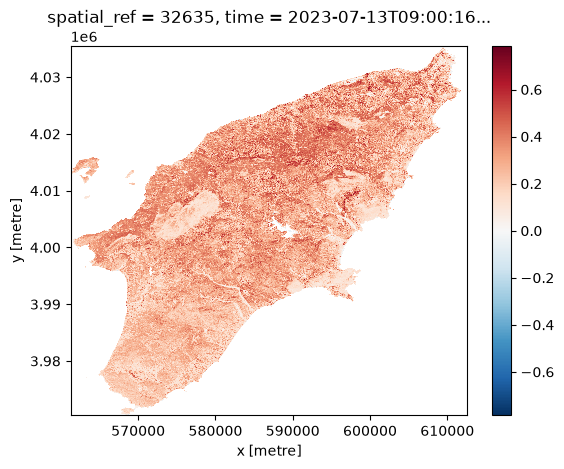

In [8]:
ndvi_before = ndvi.sel(time="2023-07-13")
ndvi_before.plot()

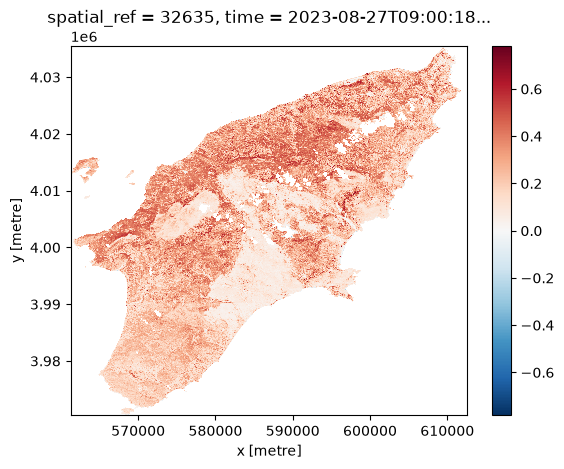

In [9]:
ndvi_after = ndvi.sel(time="2023-08-27")
ndvi_after.plot()

### NDVI time series at a point

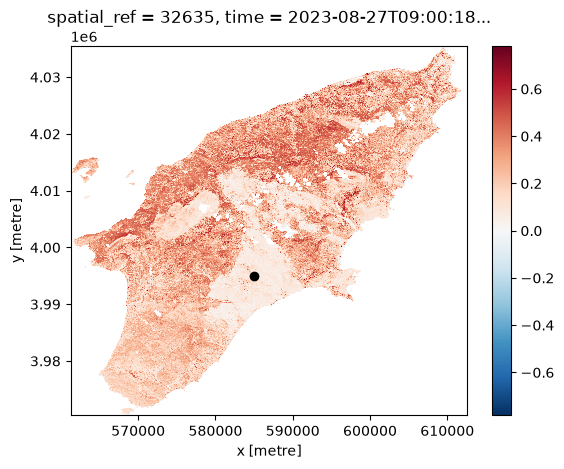

In [10]:
x = 585_000
y = 3_995_000

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ndvi_after.plot(ax=ax)
ax.scatter(x, y, marker="o", c="k")

In [11]:
ndvi_xy = ndvi.sel(x=x, y=y, method="nearest")
print(ndvi_xy)

<xarray.DataArray (time: 25)> Size: 100B
dask.array<getitem, shape=(25,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[us] 200B 2023-07-01T09:10:15.805000 ... 20...
    y            float64 8B 3.995e+06
    x            float64 8B 5.85e+05
    spatial_ref  int32 4B 32635
Attributes:
    nodata:   0


In [12]:
%%time
ndvi_xy = ndvi_xy.compute(scheduler="threads", num_workers=4)

CPU times: user 18.4 s, sys: 4.79 s, total: 23.2 s
Wall time: 2min 4s


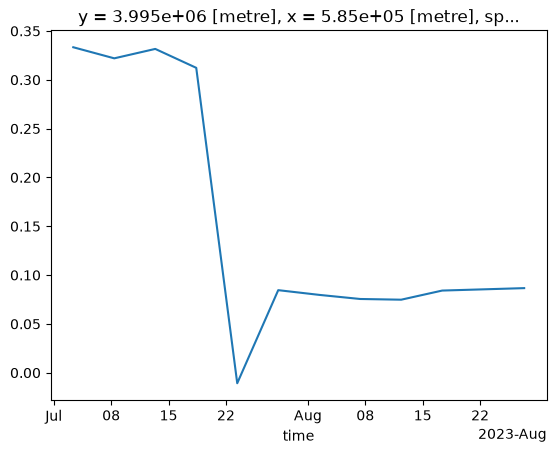

In [13]:
ndvi_xy.dropna(dim="time").plot()